In [1]:
# Set the root path to your project directory
import pathlib

root = pathlib.Path(r"c:\Users\26293\Desktop\WORK\emhass_git\emhass")
print(root)
print(list((root / "data").glob("*")))  # List files in the data folder

c:\Users\26293\Desktop\WORK\emhass_git\emhass
[WindowsPath('c:/Users/26293/Desktop/WORK/emhass_git/emhass/data/adjust_pv_regressor.pkl'), WindowsPath('c:/Users/26293/Desktop/WORK/emhass_git/emhass/data/cached-open-meteo-forecast.json'), WindowsPath('c:/Users/26293/Desktop/WORK/emhass_git/emhass/data/data_load_cost_forecast.csv'), WindowsPath('c:/Users/26293/Desktop/WORK/emhass_git/emhass/data/data_load_forecast.csv'), WindowsPath('c:/Users/26293/Desktop/WORK/emhass_git/emhass/data/data_prod_price_forecast.csv'), WindowsPath('c:/Users/26293/Desktop/WORK/emhass_git/emhass/data/data_weather_forecast.csv'), WindowsPath('c:/Users/26293/Desktop/WORK/emhass_git/emhass/data/debug-adjust-pv-forecast-data-prep-input-data.csv'), WindowsPath('c:/Users/26293/Desktop/WORK/emhass_git/emhass/data/debug-adjust-pv-forecast-data-prep-output-data.csv'), WindowsPath('c:/Users/26293/Desktop/WORK/emhass_git/emhass/data/debug-adjust-pv-forecast-predict-forecast-data.csv'), WindowsPath('c:/Users/26293/Desktop/

In [2]:
import pickle

# Load the pickle file
with open(root / "data" / "long_train_data.pkl", "rb") as inp:
    data = pickle.load(inp)

# Check the type and length of the loaded object
print(type(data))
print(len(data))

df_final, days_list, var_list, ha_config = data

# Show the DataFrame
print(df_final.head())
print("days_list:", days_list)
print("var_list:", var_list)
print("ha_config:", ha_config)

<class 'tuple'>
4
                           sensor.power_load_no_var_loads  \
2024-02-28 21:00:00+00:00                             0.0   
2024-02-28 21:30:00+00:00                             0.0   
2024-02-28 22:00:00+00:00                             NaN   
2024-02-28 22:30:00+00:00                             NaN   
2024-02-28 23:00:00+00:00                             NaN   

                           sensor.power_photovoltaics  sensor.p_pv_forecast  
2024-02-28 21:00:00+00:00                         0.0                  -1.5  
2024-02-28 21:30:00+00:00                         0.0                  -1.5  
2024-02-28 22:00:00+00:00                         NaN                   NaN  
2024-02-28 22:30:00+00:00                         NaN                   NaN  
2024-02-28 23:00:00+00:00                         NaN                   NaN  
days_list: DatetimeIndex(['2024-02-28 21:00:00+00:00', '2024-02-29 21:00:00+00:00',
               '2024-03-01 21:00:00+00:00', '2024-03-02 21:00:0

C:\Users\26293\AppData\Local\Temp\ipykernel_34900\2426249113.py:5: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data = pickle.load(inp)


In [3]:
import pickle
import pathlib
import pandas as pd
from emhass.machine_learning_forecaster import MLForecaster
from emhass.forecast import Forecast
from emhass import utils

# Setup paths and logger
root = pathlib.Path(r"c:\Users\26293\Desktop\WORK\emhass_git\emhass")
emhass_conf = {
    "data_path": root / "data/",
    "root_path": root / "src/emhass/",
    "defaults_path": root / "src/emhass/data/config_defaults.json",
    "associations_path": root / "src/emhass/data/associations.csv",
}
logger, ch = utils.get_logger("notebook", emhass_conf, save_to_file=False)

# Load test data
with open(emhass_conf["data_path"] / "long_train_data.pkl", "rb") as inp:
    df_final, days_list, var_list, ha_config = pickle.load(inp)


c:\Users\26293\Desktop\WORK\emhass_git\emhass\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
df_final.tail()

,sensor.power_load_no_var_loads,sensor.power_photovoltaics,sensor.p_pv_forecast
2025-02-27 20:30:00+00:00,3478.084000,NaN,NaN
2025-02-27 21:00:00+00:00,3409.921111,0.0,-0.55
2025-02-27 21:30:00+00:00,3344.159392,NaN,NaN
2025-02-27 22:00:00+00:00,1563.476536,NaN,NaN
2025-02-27 22:30:00+00:00,1532.535000,NaN,NaN


In [5]:
df_final.to_csv("long_train_data.csv", index=True, index_label="datetime")

In [6]:
model_type = "long_train_data"
var_model = "sensor.power_load_no_var_loads"
sklearn_model = "ElasticNet"
num_lags = 48

mlf = MLForecaster(df_final, model_type, var_model, sklearn_model, num_lags, emhass_conf, logger)
# mlf.fit()

# forecast = mlf.predict()
# forecast.tail()

In [7]:
df_pred, df_pred_backtest = mlf.fit()
print(df_pred.tail())

2025-07-15 16:36:03,336 - notebook - INFO - Performing a forecast model fit for long_train_data
2025-07-15 16:36:03,345 - notebook - INFO - Training a ElasticNet model
2025-07-15 16:36:04,797 - notebook - INFO - Elapsed time for model fit: 1.4521076679229736
2025-07-15 16:36:04,812 - notebook - INFO - Prediction R2 score of fitted model on test data: 0.40115460521565593


                           train         test         pred
2025-02-27 20:30:00+00:00    NaN  3478.084000  1770.844400
2025-02-27 21:00:00+00:00    NaN  3409.921111  1919.594767
2025-02-27 21:30:00+00:00    NaN  3344.159392  1935.211589
2025-02-27 22:00:00+00:00    NaN  1563.476536  1828.926772
2025-02-27 22:30:00+00:00    NaN  1532.535000  1732.275888


                                  test         pred
2025-02-25 23:00:00+00:00  3482.792056  1770.208932
2025-02-25 23:30:00+00:00  1557.221215  1300.836444
2025-02-26 00:00:00+00:00   914.423966  1283.535137
2025-02-26 00:30:00+00:00   266.457207  1119.135181
2025-02-26 01:00:00+00:00   232.014222   992.556553


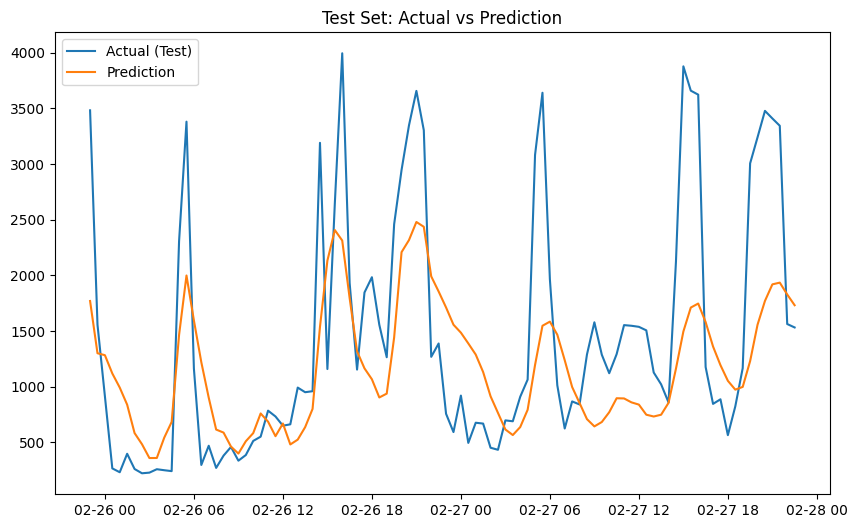

In [8]:
# Only keep rows where both test and pred are not NaN
test_comparison = df_pred[["test", "pred"]].dropna()
print(test_comparison.head())

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(test_comparison.index, test_comparison["test"], label="Actual (Test)")
plt.plot(test_comparison.index, test_comparison["pred"], label="Prediction")
plt.legend()
plt.title("Test Set: Actual vs Prediction")
plt.show()

In [9]:
import plotly.graph_objs as go
from plotly.offline import iplot

# Create interactive plot
fig = go.Figure()
fig.add_trace(go.Scatter(x=test_comparison.index, y=test_comparison["test"], mode='lines', name='Actual (Test)'))
fig.add_trace(go.Scatter(x=test_comparison.index, y=test_comparison["pred"], mode='lines', name='Prediction'))

fig.update_layout(
    title="Test Set: Actual vs Prediction (Interactive)",
    xaxis_title="Time",
    yaxis_title="Value",
    legend=dict(x=0, y=1),
    hovermode="x unified" 
)

iplot(fig)

In [10]:
df_pred, df_pred_backtest = mlf.fit(perform_backtest=True)
print(df_pred_backtest.tail())

2025-07-15 16:36:05,930 - notebook - INFO - Performing a forecast model fit for long_train_data
2025-07-15 16:36:05,940 - notebook - INFO - Training a ElasticNet model
2025-07-15 16:36:07,350 - notebook - INFO - Elapsed time for model fit: 1.4103996753692627
2025-07-15 16:36:07,367 - notebook - INFO - Prediction R2 score of fitted model on test data: 0.40115460521565593
2025-07-15 16:36:07,370 - notebook - INFO - Performing simple backtesting of fitted model
100%|██████████| 363/363 [00:01<00:00, 360.04it/s]
2025-07-15 16:36:08,383 - notebook - INFO - Elapsed backtesting time: 1.0135416984558105
2025-07-15 16:36:08,383 - notebook - INFO - Backtest R2 score:    neg_r2_score
0      0.337824


                                 train  pred
2025-02-27 20:30:00+00:00  3478.084000   NaN
2025-02-27 21:00:00+00:00  3409.921111   NaN
2025-02-27 21:30:00+00:00  3344.159392   NaN
2025-02-27 22:00:00+00:00  1563.476536   NaN
2025-02-27 22:30:00+00:00  1532.535000   NaN


In [11]:
test_backtest_comparison = df_pred_backtest[["train", "pred"]].dropna()
test_backtest_comparison.tail()

,train,pred
2025-02-25 20:30:00+00:00,3334.416333,1449.465038
2025-02-25 21:00:00+00:00,2808.148122,2601.459707
2025-02-25 21:30:00+00:00,3894.229116,2316.110785
2025-02-25 22:00:00+00:00,1286.109162,1821.826982
2025-02-25 22:30:00+00:00,2004.290331,1374.578929


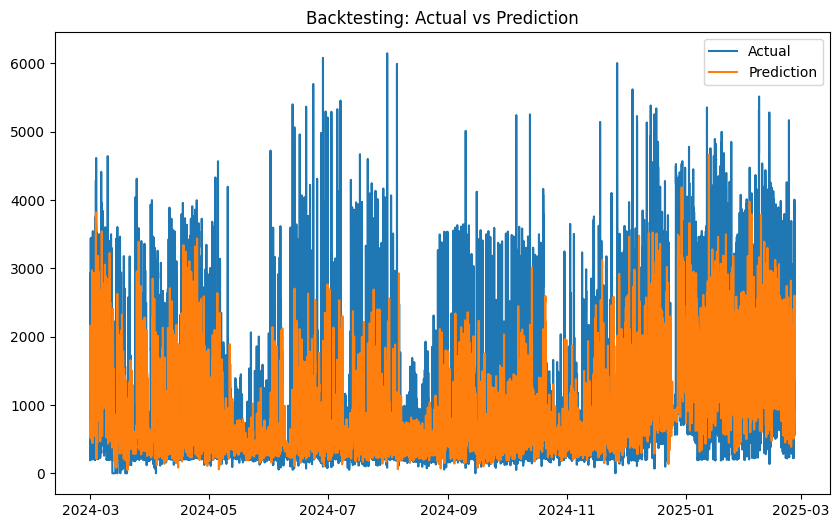

In [12]:
# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(test_backtest_comparison.index, test_backtest_comparison["train"], label="Actual")
plt.plot(test_backtest_comparison.index, test_backtest_comparison["pred"], label="Prediction")
plt.legend()
plt.title("Backtesting: Actual vs Prediction")
plt.show()

In [13]:
import plotly.graph_objs as go
from plotly.offline import iplot

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=test_backtest_comparison.index.strftime("%Y-%m-%d %H:%M:%S"),
    y=test_backtest_comparison["train"],
    mode='lines',
    name='Actual'
))
fig.add_trace(go.Scatter(
    x=test_backtest_comparison.index.strftime("%Y-%m-%d %H:%M:%S"),
    y=test_backtest_comparison["pred"],
    mode='lines',
    name='Prediction'
))

fig.update_layout(
    title="Backtesting: Actual vs Prediction (Interactive)",
    xaxis_title="Time",
    yaxis_title="Value (W)",
    legend=dict(x=0, y=1),
    hovermode="x unified",
    xaxis=dict(
        tickformat='%Y-%m-%d %H:%M:%S',
        rangeslider=dict(visible=True),  # Add slider for time selection
        rangeselector=dict(
            buttons=list([
                dict(count=1, label="1d", step="day", stepmode="backward"),
                dict(count=7, label="1w", step="day", stepmode="backward"),
                dict(step="all")
            ])
        )
    )
)

iplot(fig)

In [14]:
# Forecast next day
forecast = mlf.predict(data_last_window=df_final)
forecast.head()

2025-02-27 23:00:00+00:00    1393.954481
2025-02-27 23:30:00+00:00    1239.699932
2025-02-28 00:00:00+00:00    1330.280507
2025-02-28 00:30:00+00:00    1289.170036
2025-02-28 01:00:00+00:00    1221.170710
Freq: 30min, Name: pred, dtype: float64

In [15]:
df_pred_opt = mlf.tune()
df_pred_opt.head()

2025-07-15 16:36:08,982 - notebook - INFO - Bayesian hyperparameter optimization with backtesting
Best trial: 1. Best value: -0.33925: 100%|██████████| 10/10 [01:26<00:00,  8.68s/it] 
2025-07-15 16:37:41,262 - notebook - INFO - Elapsed time: 92.27876830101013
C:\Users\26293\Desktop\WORK\emhass_git\emhass\src\emhass\machine_learning_forecaster.py:365: FutureWarning:

Minute.delta is deprecated and will be removed in a future version. Use pd.Timedelta(obj) instead

2025-07-15 16:37:41,262 - notebook - INFO - R2 score for optimized prediction in train period: 0.3392495768854057
2025-07-15 16:37:41,262 - notebook - INFO - R2 score for optimized prediction in test period: 0.5892995739612943
2025-07-15 16:37:41,262 - notebook - INFO - Number of optimal lags obtained: 72


`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72] 
  Parameters: {'alpha': 1.4580994147680832, 'l1_ratio': 0.4385722446796244, 'selection': 'random'}
  Backtesting metric: -0.3392495768854057


,train,test,pred_optim
2024-02-28 21:00:00+00:00,0.000000,NaN,NaN
2024-02-28 21:30:00+00:00,0.000000,NaN,NaN
2024-02-28 22:00:00+00:00,27.710482,NaN,NaN
2024-02-28 22:30:00+00:00,55.420963,NaN,NaN
2024-02-28 23:00:00+00:00,83.131445,NaN,NaN


In [16]:
df_pred_opt_comparsion = df_pred_opt[["test", "pred_optim"]].dropna()
df_pred_opt_comparsion.tail()

,test,pred_optim
2025-02-26 20:30:00+00:00,3347.404278,2255.678280
2025-02-26 21:00:00+00:00,3657.588626,2081.434679
2025-02-26 21:30:00+00:00,3304.044722,2241.451521
2025-02-26 22:00:00+00:00,1268.616927,1286.779038
2025-02-26 22:30:00+00:00,1388.532667,1452.730353


In [17]:
import plotly.graph_objs as go

# Prepare comparison DataFrames
test_comparison = df_pred[['test', 'pred']].dropna()
tune_comparison = df_pred_opt[['test', 'pred_optim']].dropna()

# Align indices (if needed)
common_idx = test_comparison.index.intersection(tune_comparison.index)
test_comparison = test_comparison.loc[common_idx]
tune_comparison = tune_comparison.loc[common_idx]

# Plot
fig = go.Figure()
fig.add_trace(go.Scatter(x=common_idx, y=test_comparison['test'], mode='lines', name='Actual (Test)'))
fig.add_trace(go.Scatter(x=common_idx, y=test_comparison['pred'], mode='lines', name='Prediction (Fit)'))
fig.add_trace(go.Scatter(x=common_idx, y=tune_comparison['pred_optim'], mode='lines', name='Prediction (Tune)'))

fig.update_layout(
    title="Test Set: Actual vs Fit vs Tune Prediction",
    xaxis_title="Time",
    yaxis_title="Value",
    legend=dict(x=0, y=1),
    hovermode="x unified"
)
fig.show()